In [74]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.7.0+cu126
CUDA Available: True
GPU: NVIDIA GeForce RTX 3080


检查路径

In [75]:
import os
print(os.listdir('tensorForTesting/202505P'))

['y_train.npy', 'X_val.npy', 'scaler_b.pkl', 'scaler_a.pkl', 'X_train.npy', 'scaler_c.pkl', 'y_test.npy', 'X_test.npy', 'scaler_X.pkl', 'y_val.npy']


导入其余包

In [77]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError

导入数据

In [78]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, x_data, y_data):
        # 重排维度：(N, H, W, C) -> (N, C, H, W)
        x_data = np.transpose(x_data, (0, 3, 1, 2))  # 从 (N, 78, 20, 1) 到 (N, 1, 78, 20)
        self.x_data = torch.tensor(x_data, dtype=torch.float32)
        self.y_data = torch.tensor(y_data, dtype=torch.float32)  # Shape: (N, 3)

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        return self.x_data[idx], self.y_data[idx]

def load_data():
    # 加载 NumPy 文件
    X_train = np.load('tensorForTesting/202505P/X_train.npy')  # (400, 78, 20, 1)
    y_train = np.load('tensorForTesting/202505P/y_train.npy')  # (400, 3)
    X_valid = np.load('tensorForTesting/202505P/X_val.npy')  # (50, 78, 20, 1)
    y_valid = np.load('tensorForTesting/202505P/y_val.npy')  # (50, 3)
    X_test = np.load('tensorForTesting/202505P/X_test.npy')   # (50, 78, 20, 1)
    y_test = np.load('tensorForTesting/202505P/y_test.npy')   # (50, 3)

    # 创建数据集
    train_dataset = CustomDataset(X_train, y_train)
    valid_dataset = CustomDataset(X_valid, y_valid)
    test_dataset = CustomDataset(X_test, y_test)

    # 创建 DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)

    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}, 标签形状 {y_train.shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}, 标签形状 {y_valid.shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}, 标签形状 {y_test.shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

训练集: 400 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (400, 3)
验证集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)
测试集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)


定义CNN模型

In [79]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输入 (78, 20, 1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)  # 输出 (39, 10, 32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)  # 输出 (19, 5, 64)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(19 * 5 * 64, 128)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)  # 防止过拟合
        self.fc2 = nn.Linear(128, 3)  # 输出 [a, b, c]

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


定义训练函数

In [80]:
def train_model(model, train_loader, valid_loader, epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    mae = MeanAbsoluteError().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

    best_valid_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        train_loss, train_mae = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_mae += mae(output, y).item()
        train_loss /= len(train_loader)
        train_mae /= len(train_loader)

        model.eval()
        valid_loss, valid_mae = 0, 0
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)
                valid_loss += criterion(output, y).item()
                valid_mae += mae(output, y).item()
        valid_loss /= len(valid_loader)
        valid_mae /= len(valid_loader)

        print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Valid Loss: {valid_loss:.4f}, Valid MAE: {valid_mae:.4f}')

        # 保存最佳模型
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model.pt')

    return model


定义测试函数

In [81]:
def test_model(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.MSELoss()
    mae = MeanAbsoluteError().to(device)
    test_loss, test_mae = 0, 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            test_loss += criterion(output, y).item()
            test_mae += mae(output, y).item()
            predictions.append(output.cpu().numpy())
            trues.append(y.cpu().numpy())

    test_loss /= len(test_loader)
    test_mae /= len(test_loader)
    predictions = np.concatenate(predictions, axis=0)
    trues = np.concatenate(trues, axis=0)
    print(f'Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}')
    return test_loss, test_mae, predictions, trues

检查数据和标签是否正常，存在空值需要调整为0

In [82]:
import numpy as np

def check_data(file_path):
    data = np.load(file_path)
    print(f"{file_path}: shape={data.shape}, has_nan={np.any(np.isnan(data))}, has_inf={np.any(np.isinf(data))}")

files = [
    'tensorForTesting/202505P/X_train.npy',
    'tensorForTesting/202505P/y_train.npy',
    'tensorForTesting/202505P/X_val.npy',
    'tensorForTesting/202505P/y_val.npy',
    'tensorForTesting/202505P/X_test.npy',
    'tensorForTesting/202505P/y_test.npy'
]
for f in files:
    check_data(f)

tensorForTesting/202505P/X_train.npy: shape=(400, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/202505P/y_train.npy: shape=(400, 3), has_nan=False, has_inf=False
tensorForTesting/202505P/X_val.npy: shape=(50, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/202505P/y_val.npy: shape=(50, 3), has_nan=False, has_inf=False
tensorForTesting/202505P/X_test.npy: shape=(50, 78, 20, 1), has_nan=False, has_inf=False
tensorForTesting/202505P/y_test.npy: shape=(50, 3), has_nan=False, has_inf=False


替换空值nan为0，替换无限大值inf为1e6

In [ ]:
#执行完成后务必重新执行上一个单元格以确认
def clean_data(input_path, output_path):
    data = np.load(input_path)
    data = np.nan_to_num(data, nan=0.0, posinf=1e6, neginf=-1e6)
    np.save(output_path, data)

files = [
    'tensorForTesting/202505P/X_train.npy',
]   #根据上一个单元格输出选择需要替换的文件名
for f in files:
    clean_data(f, f)

检查数据和标签是否归一化

In [ ]:
def data_stats(file_path):
    data = np.load(file_path)
    print(f{file_path}: min={np.min(data)}, max={np.max(data)}, mean={np.mean(data)}, std={np.std(data)})

files = [
    'tensorForTesting/202505P/X_train.npy',
    'tensorForTesting/202505P/y_train.npy',
    'tensorForTesting/202505P/X_val.npy',
    'tensorForTesting/202505P/y_val.npy',
    'tensorForTesting/202505P/X_test.npy',
    'tensorForTesting/202505P/y_test.npy'
]
for f in files:
    data_stats(f)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1667273789.py, line 3)

主程序：加载数据、训练和测试

In [83]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练
model = train_model(model, train_loader, valid_loader)

# 加载最佳模型
model.load_state_dict(torch.load('best_model.pt'))

# 测试
test_model(model, test_loader)


训练集: 400 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (400, 3)
验证集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)
测试集: 50 样本, 数据形状 torch.Size([1, 78, 20]), 标签形状 (50, 3)
Epoch 1, Train Loss: 0.4762, Train MAE: 0.5087, Valid Loss: 0.3282, Valid MAE: 0.4157
Epoch 2, Train Loss: 0.3751, Train MAE: 0.4217, Valid Loss: 0.3134, Valid MAE: 0.4003
Epoch 3, Train Loss: 0.3633, Train MAE: 0.4175, Valid Loss: 0.2908, Valid MAE: 0.3958
Epoch 4, Train Loss: 0.3224, Train MAE: 0.3956, Valid Loss: 0.2318, Valid MAE: 0.3592
Epoch 5, Train Loss: 0.2437, Train MAE: 0.3515, Valid Loss: 0.1229, Valid MAE: 0.2703
Epoch 6, Train Loss: 0.1481, Train MAE: 0.2863, Valid Loss: 0.1106, Valid MAE: 0.2651
Epoch 7, Train Loss: 0.1088, Train MAE: 0.2512, Valid Loss: 0.0718, Valid MAE: 0.1977
Epoch 8, Train Loss: 0.0927, Train MAE: 0.2279, Valid Loss: 0.0874, Valid MAE: 0.2435
Epoch 9, Train Loss: 0.0910, Train MAE: 0.2316, Valid Loss: 0.0873, Valid MAE: 0.2523
Epoch 10, Train Loss: 0.0849, Train MAE: 0.2206, Valid Loss

(0.04732755199074745,
 0.13690191879868507,
 array([[ 0.55902946, -1.1092243 ,  0.4746458 ],
        [ 0.5262359 , -0.9844458 ,  0.20182481],
        [ 0.4978202 , -0.8744088 ,  0.1971466 ],
        [ 0.4789701 , -0.4899304 ,  0.17034326],
        [ 0.54208606, -0.27376258,  0.6352496 ],
        [ 0.5424125 , -0.17892131,  0.63292485],
        [ 0.48074156, -0.17801538,  0.45577896],
        [ 0.5116137 ,  0.1436517 ,  0.9154127 ],
        [ 0.54884785,  1.5138054 ,  0.36998683],
        [ 0.44677174,  1.7362702 ,  0.6412732 ],
        [ 0.5519614 , -1.0804704 ,  0.43489254],
        [ 0.53511983, -1.0198247 ,  0.20608556],
        [ 0.48270845, -0.8179084 ,  0.19373676],
        [ 0.48116612, -0.81222355,  0.19328612],
        [ 0.48090452, -0.81121767,  0.1942908 ],
        [ 0.4878747 , -0.375435  ,  0.16831169],
        [ 0.54208606, -0.27376258,  0.6352496 ],
        [ 0.47587293, -0.26431584,  0.45203257],
        [ 0.5561316 , -0.06736258,  0.6189871 ],
        [ 0.51853526,  0.

测试集参数估计可视化

Test Loss: 0.0473, Test MAE: 0.1369
测试集前 10 个样本的预测结果：
 Sample  True_LW feedback  Pred_LW feedback  Error_LW feedback  True_f_*  Pred_f_*  Error_f_*  True_lg(L_X/SFR)  Pred_lg(L_X/SFR)  Error_lg(L_X/SFR)
      0               0.0          2.236118           2.236118  0.003613  0.003794   0.000181         37.676258         37.381042           0.295216
      1               0.0          2.104944           2.104944  0.004866  0.004791   0.000076         35.613922         36.025181           0.411259
      2               0.0          1.991281           1.991281  0.005880  0.005670   0.000211         35.811352         36.001930           0.190578
      3               0.0          1.915880           1.915880  0.008890  0.008741   0.000150         35.927765         35.868725           0.059040
      4               0.0          2.168344           2.168344  0.010000  0.010468   0.000468         38.000000         38.179214           0.179214
      5               0.0          2.169650         

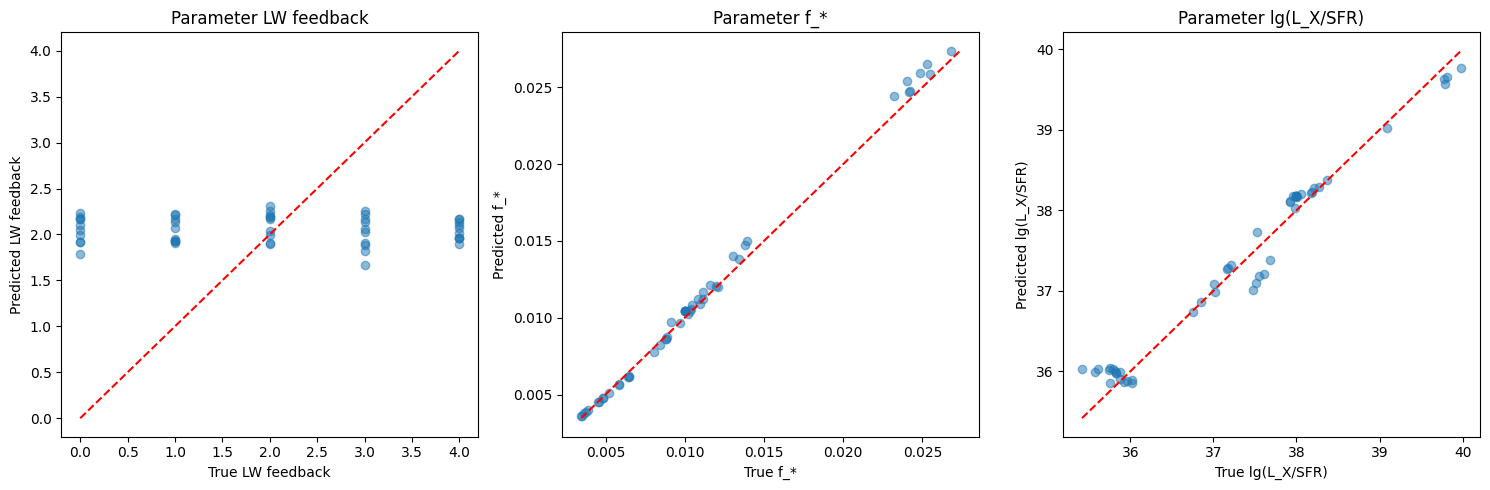

散点图已保存至 scatter_plot.png


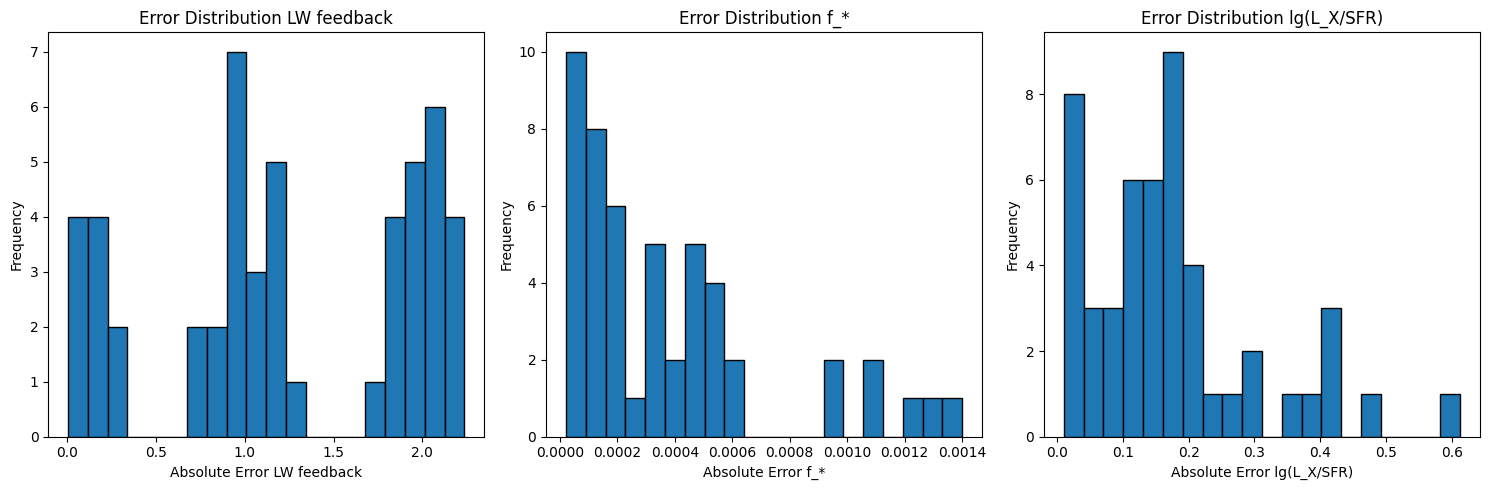

误差直方图已保存至 error_histogram.png


In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib

def visualize_predictions(predictions, trues, table_path='predictions_table.csv', scatter_path='scatter_plot.png', hist_path='error_histogram.png'):
    # 加载归一化器
    scaler_a = joblib.load('tensorForTesting/202505P/scaler_a.pkl')
    scaler_b = joblib.load('tensorForTesting/202505P/scaler_b.pkl')
    scaler_c = joblib.load('tensorForTesting/202505P/scaler_c.pkl')

    # 反归一化 predictions 和 trues
    predictions_denorm = np.zeros_like(predictions)
    trues_denorm = np.zeros_like(trues)
    predictions_denorm[:, 0] = scaler_a.inverse_transform(predictions[:, 0:1].reshape(-1, 1)).flatten()
    predictions_denorm[:, 1] = scaler_b.inverse_transform(predictions[:, 1:2].reshape(-1, 1)).flatten()
    predictions_denorm[:, 2] = scaler_c.inverse_transform(predictions[:, 2:3].reshape(-1, 1)).flatten()
    trues_denorm[:, 0] = scaler_a.inverse_transform(trues[:, 0:1].reshape(-1, 1)).flatten()
    trues_denorm[:, 1] = scaler_b.inverse_transform(trues[:, 1:2].reshape(-1, 1)).flatten()
    trues_denorm[:, 2] = scaler_c.inverse_transform(trues[:, 2:3].reshape(-1, 1)).flatten()

    # 表格：前 10 个样本的预测和真实值
    n_samples = min(10, len(predictions))
    df = pd.DataFrame({
        'Sample': range(n_samples),
        'True_LW feedback': trues_denorm[:n_samples, 0],
        'Pred_LW feedback': predictions_denorm[:n_samples, 0],
        'Error_LW feedback': np.abs(trues_denorm[:n_samples, 0] - predictions_denorm[:n_samples, 0]),
        'True_f_*': trues_denorm[:n_samples, 1],
        'Pred_f_*': predictions_denorm[:n_samples, 1],
        'Error_f_*': np.abs(trues_denorm[:n_samples, 1] - predictions_denorm[:n_samples, 1]),
        'True_lg(L_X/SFR)': trues_denorm[:n_samples, 2],
        'Pred_lg(L_X/SFR)': predictions_denorm[:n_samples, 2],
        'Error_lg(L_X/SFR)': np.abs(trues_denorm[:n_samples, 2] - predictions_denorm[:n_samples, 2])
    })
    print("测试集前 10 个样本的预测结果：")
    print(df.to_string(index=False))
    df.to_csv(table_path, index=False)
    print(f"表格已保存至 {table_path}")

    # 散点图：预测 vs. 真实值
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    labels = ['LW feedback', 'f_*', 'lg(L_X/SFR)']
    for i, ax in enumerate(axes):
        ax.scatter(trues_denorm[:, i], predictions_denorm[:, i], alpha=0.5)
        min_val = min(trues_denorm[:, i].min(), predictions_denorm[:, i].min())
        max_val = max(trues_denorm[:, i].max(), predictions_denorm[:, i].max())    
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')
        ax.set_xlabel(f'True {labels[i]}')
        ax.set_ylabel(f'Predicted {labels[i]}')
        ax.set_title(f'Parameter {labels[i]}')
    plt.tight_layout()
    plt.savefig(scatter_path)
    plt.show()
    print(f"散点图已保存至 {scatter_path}")

    # 误差分布直方图
    errors = np.abs(trues_denorm - predictions_denorm)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.hist(errors[:, i], bins=20, edgecolor='black')
        ax.set_xlabel(f'Absolute Error {labels[i]}')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Error Distribution {labels[i]}')
    plt.tight_layout()
    plt.savefig(hist_path)
    plt.show()
    print(f"误差直方图已保存至 {hist_path}")

test_loss, test_mae, predictions, trues = test_model(model, test_loader)
visualize_predictions(predictions, trues)